# GRPO from scratch — a tiny language model learns arithmetic from a verifier

This notebook trains a **58k-parameter** GPT on the world's smallest RL task, end to end:

| stage | what happens | accuracy |
|---|---|---|
| 1. pretrain | next-token prediction on **noisy** data (half the answers are wrong) | ~46% |
| 2. GRPO | model generates groups of answers, a verifier grades them, gradients follow | ~95% |

Everything runs on CPU in a few minutes. Every number you see below is printed by the code above it — nothing is pasted in.

**How this fits the course** (`courses/rl_demos/`): chapter 7 explains the GRPO *idea*; chapter 8 walks this exact update with diagrams; chapters 9–12 cover on/off-policy, the difficulty curriculum, on-policy distillation, and the MoE serving gap. This notebook is the *working machine* those chapters point at.

The plan:

1. a 13-token tokenizer and a tiny GPT — the **policy**
2. pretrain on noisy data — a deliberately mediocre **base model**
3. the **verifier** — the entire "reward model" is 6 lines of Python
4. one GRPO update **under the microscope** — every tensor printed
5. the full training loop — watch accuracy climb and watch the **signal dry up** (the curriculum problem, live)

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import random, copy, warnings
warnings.filterwarnings("ignore")   # silence a PyTorch nested-tensor perf hint

torch.manual_seed(0)
random.seed(0)

## 1. The world's smallest tokenizer

Our language has 13 tokens: the digits `0-9`, `+`, `=`, and `.` — the period is our end-of-answer token (a stand-in for `<EOS>`).

A problem is the string `"3+4="`. The model must continue it with answer digits and then `.` to stop.

In [2]:
CHARS = "0123456789+=."
stoi = {c: i for i, c in enumerate(CHARS)}
itos = {i: c for i, c in enumerate(CHARS)}
V = len(CHARS)
EOS = stoi["."]

def encode(s): return [stoi[c] for c in s]
def decode(t): return "".join(itos[i] for i in t)

print("vocab size:", V)
print("encode('3+4='):", encode("3+4="))
print("decode([7, 12]):", repr(decode([7, 12])))   # the answer '7' + end-of-answer

vocab size: 13
encode('3+4='): [3, 10, 4, 11]
decode([7, 12]): '7.'


## 2. The policy — a tiny GPT

2 transformer layers, 48-dim embeddings, causal mask, ~58k parameters. This *is* the `pi_theta` from every RL formula — a language model **is** a policy: given the tokens so far (the state), it outputs a probability for each next token (the actions).

In [3]:
class TinyGPT(nn.Module):
    def __init__(self, vocab=V, d=48, n_head=3, n_layer=2, max_len=8):
        super().__init__()
        self.tok = nn.Embedding(vocab, d)
        self.pos = nn.Embedding(max_len, d)
        block = nn.TransformerEncoderLayer(
            d_model=d, nhead=n_head, dim_feedforward=4 * d,
            dropout=0.0, batch_first=True, norm_first=True)
        self.blocks = nn.TransformerEncoder(block, num_layers=n_layer)
        self.head = nn.Linear(d, vocab)

    def forward(self, idx):                       # idx: (batch, time)
        B, T = idx.shape
        x = self.tok(idx) + self.pos(torch.arange(T))
        causal = torch.triu(torch.ones(T, T, dtype=torch.bool), diagonal=1)
        x = self.blocks(x, mask=causal)
        return self.head(x)                       # (batch, time, vocab)

model = TinyGPT()
print("parameters:", sum(p.numel() for p in model.parameters()))

parameters: 58189


## 3. Stage 1 — make a mediocre base model *on purpose*

Real GRPO starts from a pretrained model that already solves the task *sometimes*. We fake that history: pretrain on addition data where **half the answers are wrong** (a random number instead of the true sum).

Why sabotage our own data? Because it puts the model exactly where GRPO wants it: right about half the time. Hold that thought —

- if the base model were **always wrong**, every group GRPO samples would score `[0,0,0,...]` — no signal (you'll see why in §6);
- if it were **always right**, every group would score `[1,1,1,...]` — also no signal.

A ~50% model is the sweet spot. This "the task must be neither too hard nor too easy" constraint is a real production pain point — chapter 10 of the course is entirely about it.

In [4]:
def make_example():
    a, b = random.randint(0, 9), random.randint(0, 9)
    if random.random() < 0.5:
        c = a + b                     # correct answer
    else:
        c = random.randint(0, 18)     # random junk
    return f"{a}+{b}={c}."

for _ in range(6):
    print(make_example())

6+6=12.
8+7=15.
4+7=11.
3+8=11.
2+1=8.
8+9=9.


Standard next-token cross-entropy, with the loss masked to the answer tokens only (the model isn't trained to predict the problem, just the answer). This is ordinary SFT — no RL yet.

In [5]:
opt = torch.optim.AdamW(model.parameters(), lr=3e-4)

def batch_pretrain(bs=64):
    seqs = [encode(make_example()) for _ in range(bs)]
    L = max(len(s) for s in seqs)
    x = torch.full((bs, L), EOS, dtype=torch.long)      # pad with EOS
    for i, s in enumerate(seqs):
        x[i, :len(s)] = torch.tensor(s)
    inp, tgt = x[:, :-1], x[:, 1:].clone()
    for i, s in enumerate(seqs):
        eq = s.index(stoi["="])
        tgt[i, :eq] = -100            # don't train on prompt positions
        tgt[i, len(s) - 1:] = -100    # don't train on padding
    return inp, tgt

for step in range(3001):
    inp, tgt = batch_pretrain()
    logits = model(inp)
    loss = F.cross_entropy(logits.reshape(-1, V), tgt.reshape(-1), ignore_index=-100)
    opt.zero_grad(); loss.backward(); opt.step()
    if step % 500 == 0:
        print(f"pretrain step {step:4d}   loss {loss.item():.3f}")

pretrain step    0   loss 2.803


pretrain step  500   loss 1.132


pretrain step 1000   loss 0.947


pretrain step 1500   loss 0.920


pretrain step 2000   loss 1.046


pretrain step 2500   loss 0.951


pretrain step 3000   loss 0.822


The loss flattens near ~0.9 and **cannot go lower** — the data itself is 50% noise, and cross-entropy faithfully learns to reproduce that noise. SFT's ceiling is the quality of its data. That's the wall GRPO will break through, because its verifier — unlike the training data — is never wrong.

## 4. The verifier — the entire "reward model" is 6 lines

First, sampling: given prompts, the model writes up to 3 tokens (enough for a 2-digit answer plus `.`).

Then the reward function. For math with known answers you don't need a neural reward model — you need a **grader**: parse the digits before `.`, compare to `a+b`. Right = `1.0`, anything else = `0.0`. Binary, unfoolable, and exactly what DeepSeek-R1 does at scale (plus formatting checks).

In [6]:
@torch.no_grad()
def generate(model, prompts, max_new=3, greedy=False):
    """prompts: list of equal-length token lists -> list of response token lists"""
    x = torch.tensor(prompts)
    done = [False] * len(prompts)
    resp = [[] for _ in prompts]
    for _ in range(max_new):
        logits = model(x)[:, -1, :]
        if greedy:
            nxt = logits.argmax(-1, keepdim=True)
        else:
            nxt = torch.multinomial(F.softmax(logits, -1), 1)
        x = torch.cat([x, nxt], 1)
        for i, t in enumerate(nxt.squeeze(1).tolist()):
            if not done[i]:
                resp[i].append(t)
                if t == EOS:
                    done[i] = True
        if all(done):
            break
    return resp

def reward_fn(a, b, resp_tokens):
    s = decode(resp_tokens)
    if "." not in s:
        return 0.0                     # never stopped -> fail
    ans = s[:s.index(".")]
    if not ans.isdigit():
        return 0.0                     # e.g. answered '+3.' -> fail
    return 1.0 if int(ans) == a + b else 0.0

print(reward_fn(3, 4, encode("7.")))     # correct
print(reward_fn(3, 4, encode("8.")))     # wrong number
print(reward_fn(3, 4, encode("77")))     # never wrote '.'

1.0
0.0
0.0


In [7]:
def accuracy(model, n=200):
    probs = [(random.randint(0, 9), random.randint(0, 9)) for _ in range(n)]
    resps = generate(model, [encode(f"{a}+{b}=") for a, b in probs])
    return sum(reward_fn(a, b, r) for (a, b), r in zip(probs, resps)) / n

print("accuracy after noisy pretraining:", accuracy(model, n=400))

accuracy after noisy pretraining: 0.48


Roughly the 50% the data taught it. Now — RL.

## 5. One GRPO update under the microscope

Before the training loop, do **one** update in slow motion and print every tensor. This section is the whole algorithm; the loop in §10 just repeats it.

Take one prompt, `3+4=`, and let the model answer it **G = 4** times (the *group*). Same prompt, sampling on — so the answers differ. Grade each one.

In [8]:
GRPO_LR = 1e-4
opt = torch.optim.AdamW(model.parameters(), lr=GRPO_LR)   # fresh optimizer for RL
ref = copy.deepcopy(model).eval()                          # frozen reference copy, for the KL term
for p in ref.parameters():
    p.requires_grad_(False)

torch.manual_seed(7)
a, b = 3, 4
P = 4                                   # prompt length: '3','+','4','='
prompt = encode("3+4=")
group = generate(model, [prompt] * 4)

rewards = torch.tensor([reward_fn(a, b, r) for r in group])
for i, r in enumerate(group):
    print(f"response {i}: {decode(r)!r:6}   reward = {rewards[i].item():.1f}")

response 0: '10.'    reward = 0.0
response 1: '11.'    reward = 0.0
response 2: '7.'     reward = 1.0
response 3: '18.'    reward = 0.0


## 6. The group-relative advantage — GRPO's one big idea

PPO answers "was this response good?" with a trained critic network. GRPO answers it with the group itself: **good = better than my own other attempts at the same prompt.**

$$\hat{A}_i = \frac{r_i - \mathrm{mean}(r_1..r_G)}{\mathrm{std}(r_1..r_G)}$$

That's a z-score. Above the group average → positive → push up. Below → negative → push down.

In [9]:
mean, std = rewards.mean(), rewards.std(correction=0)
adv = (rewards - mean) / (std + 1e-4)

print("rewards   :", rewards.tolist())
print("group mean:", mean.item())
print("group std :", round(std.item(), 4))
print("advantages:", [round(x, 2) for x in adv.tolist()])

rewards   : [0.0, 0.0, 1.0, 0.0]
group mean: 0.25
group std : 0.433
advantages: [-0.58, -0.58, 1.73, -0.58]


Notice what the mean just did: it played the role of PPO's critic — "how well do I *usually* do on this prompt?" — computed from 4 samples instead of a second 7B network.

And notice the failure mode hiding in the denominator: if all 4 rewards were equal (all right or all wrong), then `r_i - mean = 0` for every response — **every advantage is 0 and this prompt contributes nothing to the gradient**. Remember this; it becomes the main character in §11.

<details><summary>Why divide by std at all?</summary>

Dividing by std makes the signal size independent of the reward scale — a group scored `[1,0,1,0]` and a group scored `[10,0,10,0]` produce the same advantages. Some variants disagree with this choice: <em>Dr. GRPO</em> (Liu et al. 2025) drops the std division because it over-amplifies near-unanimous groups (std → 0 blows the z-score up), and the original scale `r - mean` is already meaningful for binary rewards. Implementations also differ on population vs sample std (we use population, `correction=0`; TRL uses sample std). The mean-subtraction is the essential part.
</details>

## 7. From one number per response to one number per *token*

The advantage is per-**response**, but the model is trained token by token. GRPO's answer is blunt: **every token in a response inherits the whole response's advantage.** If `'7.'` scored +1.0, then producing `'7'` after `3+4=` gets +1.0 *and* producing `'.'` after `3+4=7` gets +1.0.

So we need each response token's log-probability under the model. One forward pass over `prompt+response`, `log_softmax`, then pick out the log-prob of the token that was actually sampled — **only at response positions** (the prompt was given, not generated; it gets no gradient — same masking idea as §3).

In [10]:
def pack(prompts, resps):
    """prompt+response into one padded tensor + how long each response is"""
    resp_len = [len(r) for r in resps]
    T = len(prompts[0]) + max(resp_len)
    full = torch.full((len(resps), T), EOS, dtype=torch.long)
    for i, (p, r) in enumerate(zip(prompts, resps)):
        full[i, :len(p)] = torch.tensor(p)
        full[i, len(p):len(p) + len(r)] = torch.tensor(r)
    return full, resp_len

def response_logprobs(model, full, P, resp_len):
    """log pi(token | everything before it), for response positions only"""
    logits = model(full[:, :-1])                       # predict token t+1 from prefix ..t
    lp = F.log_softmax(logits, dim=-1)
    token_lp = lp.gather(-1, full[:, 1:].unsqueeze(-1)).squeeze(-1)   # (B, T-1)
    mask = torch.zeros_like(token_lp)
    for i, L in enumerate(resp_len):
        mask[i, P - 1: P - 1 + L] = 1.0                # positions that PREDICT response tokens
    return token_lp, mask

full, resp_len = pack([prompt] * 4, group)
token_lp, mask = response_logprobs(model, full, P, resp_len)

print("one row per response, one column per generated token:")
for i in range(4):
    toks = [decode([t]) for t in group[i]]
    lps  = token_lp[i, P - 1: P - 1 + resp_len[i]]
    cells = "  ".join(f"'{tk}': {l.item():6.3f} (p={l.exp().item():.2f})" for tk, l in zip(toks, lps))
    print(f"response {i} {decode(group[i])!r:6} adv {adv[i].item():+.1f} | {cells}")

one row per response, one column per generated token:
response 0 '10.'  adv -0.6 | '1': -1.336 (p=0.26)  '0': -2.371 (p=0.09)  '.': -0.000 (p=1.00)
response 1 '11.'  adv -0.6 | '1': -1.336 (p=0.26)  '1': -1.742 (p=0.18)  '.': -0.002 (p=1.00)
response 2 '7.'   adv +1.7 | '7': -0.538 (p=0.58)  '.': -0.000 (p=1.00)
response 3 '18.'  adv -0.6 | '1': -1.336 (p=0.26)  '8': -2.599 (p=0.07)  '.': -0.000 (p=1.00)


## 8. The GRPO loss — every symbol is a number you just saw

For response $i$, token $t$:

$$\rho_{i,t} = \frac{\pi_\theta(o_{i,t})}{\pi_{old}(o_{i,t})} \qquad
L = -\frac{1}{G}\sum_i \frac{1}{|o_i|}\sum_t \Big[\min\big(\rho_{i,t}\hat A_i,\; \mathrm{clip}(\rho_{i,t}, 1\pm\epsilon)\hat A_i\big) - \beta\, \widehat{KL}_{i,t}\Big]$$

| symbol | meaning | value here |
|---|---|---|
| $\hat A_i$ | group z-score of response $i$ | §6 above |
| $\pi_\theta$ | model being trained | current weights |
| $\pi_{old}$ | snapshot that generated the group | identical right now → $\rho = 1$ |
| $\epsilon$ | PPO clip width | 0.2 |
| $\widehat{KL}$ | penalty for drifting from the frozen `ref` model | tiny, ~0 right now |
| $\beta$ | KL weight | 0.02 |

Two of those need honest explanations:

**The ratio is all 1s — is the update dead?** No. The *value* $\rho=1$ is constant, but $\rho$ is a function of the weights: $\rho = e^{\log\pi_\theta - \log\pi_{old}}$, so $\nabla_\theta\, \rho\hat A_i = \rho\,\hat A_i \nabla_\theta \log\pi_\theta = \hat A_i\,\nabla_\theta\log\pi_\theta$ at $\rho=1$ — exactly the REINFORCE gradient, advantage-weighted. The ratio/clip machinery only *changes* anything when you reuse a batch for several updates and $\rho$ drifts from 1 (we demo this in §9½).

**Why a KL term against `ref`?** The verifier only checks the final number. Without a leash, the model can drift into degenerate text that happens to end in the right digits. The KL penalty anchors it to the pretrained model. (We use the low-variance "k3" estimator $e^{-d} + d - 1$, $d = \log\pi_\theta - \log\pi_{ref}$, from the DeepSeekMath paper.)

In [11]:
CLIP, BETA = 0.2, 0.02

with torch.no_grad():                     # snapshot BEFORE updating: this is pi_old
    old_lp = token_lp.detach()
    ref_lp, _ = response_logprobs(ref, full, P, resp_len)

new_lp, _ = response_logprobs(model, full, P, resp_len)   # pi_theta, WITH gradients

ratio     = torch.exp(new_lp - old_lp)
unclipped = ratio * adv.unsqueeze(1)
clipped   = torch.clamp(ratio, 1 - CLIP, 1 + CLIP) * adv.unsqueeze(1)
pg_term   = -torch.min(unclipped, clipped)

d  = ref_lp - new_lp
kl = torch.exp(d) - d - 1                 # k3 estimator, per token

per_token = pg_term + BETA * kl
loss = ((per_token * mask).sum(1) / mask.sum(1)).mean()

print("ratio (response tokens, first row):", [round(r, 3) for r in ratio[0, P-1:P-1+resp_len[0]].tolist()])
print("kl    (response tokens, first row):", [round(k, 5) for k in kl[0, P-1:P-1+resp_len[0]].tolist()])
print("loss :", round(loss.item(), 4))

ratio (response tokens, first row): [1.0, 1.0, 1.0]
kl    (response tokens, first row): [0.0, 0.0, 0.0]
loss : 0.0


**Don't read the loss value.** At $\rho=1$ the loss is $-\mathrm{mean}(\hat A)$, and z-scores sum to zero by construction — so GRPO's loss prints ≈ 0 *every step, forever*. The information is in the gradient inside it, not the number. (This is why people monitoring GRPO runs watch the **reward curve**, never the loss curve.)

## 9. The update — watch probabilities move

`loss.backward()` sends the advantage down through `log_softmax` into every weight; the optimizer nudges them. If GRPO works, one step should make the model *more* likely to produce its above-average answers and *less* likely to produce its below-average ones — on this prompt.

We measure P(whole response) = product of its token probabilities, for one positively-scored and one negatively-scored response from the group.

In [12]:
@torch.no_grad()
def seq_prob(model, resp_tokens):
    f, rl = pack([prompt], [resp_tokens])
    lp, m = response_logprobs(model, f, P, rl)
    return (lp * m).sum().exp().item()

up_i   = int((adv > 0).nonzero()[0])       # a response GRPO wants MORE of
down_i = int((adv < 0).nonzero()[0])       # a response GRPO wants LESS of

before_up, before_down = seq_prob(model, group[up_i]), seq_prob(model, group[down_i])

opt.zero_grad(); loss.backward(); opt.step()          # <- the actual GRPO update

after_up, after_down = seq_prob(model, group[up_i]), seq_prob(model, group[down_i])

print(f"P({decode(group[up_i])!r} | '3+4=')  adv {adv[up_i].item():+.1f}:  {before_up:.4f} -> {after_up:.4f}")
print(f"P({decode(group[down_i])!r} | '3+4=')  adv {adv[down_i].item():+.1f}:  {before_down:.4f} -> {after_down:.4f}")

P('7.' | '3+4=')  adv +1.7:  0.5839 -> 0.6399
P('10.' | '3+4=')  adv -0.6:  0.0245 -> 0.0195


That's GRPO. One prompt, four attempts, a grader, a z-score, and one gradient step that moved probability mass from the bad attempt to the good ones. Everything else is repetition.

## 9½. When does the clip ever fire?

In the step above, $\rho = 1$ everywhere, so the clip did nothing. It matters when you take **several** optimizer steps on the *same* rollout data (PPO-style epochs — how real frameworks squeeze more learning from expensive generations). Keep stepping on this one stale group — always measuring $\rho$ against the *original* snapshot — and watch the ratios drift away from 1 until tokens start crossing $1\pm0.2$. A clipped token's gradient is exactly **zero**: "you've moved far enough on this stale data, stop" (chapter 5's PPO story, now in real tensors).

In [13]:
for pas in range(2, 6):
    new_lp_e, _ = response_logprobs(model, full, P, resp_len)
    ratio_e = torch.exp(new_lp_e - old_lp)        # vs the ORIGINAL snapshot
    r_resp = ratio_e[mask.bool()]
    n_clip = int(((r_resp < 1 - CLIP) | (r_resp > 1 + CLIP)).sum())
    print(f"pass {pas}: ratio range [{r_resp.min():.3f}, {r_resp.max():.3f}]   "
          f"clipped tokens: {n_clip}/{len(r_resp)}")
    loss_e = ((-torch.min(ratio_e * adv[:, None],
                          torch.clamp(ratio_e, 1 - CLIP, 1 + CLIP) * adv[:, None])
               * mask).sum(1) / mask.sum(1)).mean()
    opt.zero_grad(); loss_e.backward(); opt.step()

pass 2: ratio range [0.851, 1.096]   clipped tokens: 0/11
pass 3: ratio range [0.714, 1.185]   clipped tokens: 3/11
pass 4: ratio range [0.605, 1.259]   clipped tokens: 4/11
pass 5: ratio range [0.528, 1.313]   clipped tokens: 5/11


## 10. The full training loop — §5-§9 in a function

New each step: many prompts at once (8 prompts × G=8 responses = 64 sequences), and one bookkeeping number we'll need later: the fraction of groups whose rewards were **all equal** — the zero-signal groups from §6.

In [14]:
G, N_PROMPTS = 8, 8

def grpo_step(model):
    # 1. fresh prompts, G attempts each
    probs = [(random.randint(0, 9), random.randint(0, 9)) for _ in range(N_PROMPTS)]
    flat_prompts = [encode(f"{a}+{b}=") for a, b in probs for _ in range(G)]
    flat_ab      = [(a, b) for a, b in probs for _ in range(G)]
    resps = generate(model, flat_prompts)

    # 2. verify
    rewards = torch.tensor([reward_fn(a, b, r) for (a, b), r in zip(flat_ab, resps)])

    # 3. group-relative advantage
    r = rewards.view(N_PROMPTS, G)
    adv = ((r - r.mean(1, keepdim=True)) / (r.std(1, correction=0, keepdim=True) + 1e-4)).view(-1)
    zero_signal = (r.std(1) == 0).float().mean().item()

    # 4. loss, exactly as in §8
    full, resp_len = pack(flat_prompts, resps)
    with torch.no_grad():
        old_lp, mask = response_logprobs(model, full, P, resp_len)
        ref_lp, _    = response_logprobs(ref, full, P, resp_len)
    new_lp, _ = response_logprobs(model, full, P, resp_len)
    ratio     = torch.exp(new_lp - old_lp)
    pg   = -torch.min(ratio * adv[:, None],
                      torch.clamp(ratio, 1 - CLIP, 1 + CLIP) * adv[:, None])
    d    = ref_lp - new_lp
    kl   = torch.exp(d) - d - 1
    loss = (((pg + BETA * kl) * mask).sum(1) / mask.sum(1).clamp(min=1)).mean()

    opt.zero_grad(); loss.backward(); opt.step()
    return rewards.mean().item(), zero_signal

history = []
for step in range(401):
    pass_rate, zero_signal = grpo_step(model)
    if step % 50 == 0:
        acc = accuracy(model)
        history.append((step, pass_rate, zero_signal, acc))
        print(f"step {step:3d}   batch pass rate {pass_rate:.2f}   "
              f"zero-signal groups {zero_signal:.2f}   eval accuracy {acc:.2f}")

step   0   batch pass rate 0.55   zero-signal groups 0.00   eval accuracy 0.48


step  50   batch pass rate 0.66   zero-signal groups 0.00   eval accuracy 0.61


step 100   batch pass rate 0.77   zero-signal groups 0.12   eval accuracy 0.83


step 150   batch pass rate 0.75   zero-signal groups 0.12   eval accuracy 0.83


step 200   batch pass rate 0.86   zero-signal groups 0.25   eval accuracy 0.86


step 250   batch pass rate 0.91   zero-signal groups 0.50   eval accuracy 0.91


step 300   batch pass rate 0.91   zero-signal groups 0.62   eval accuracy 0.91


step 350   batch pass rate 0.89   zero-signal groups 0.38   eval accuracy 0.95


step 400   batch pass rate 0.94   zero-signal groups 0.50   eval accuracy 0.94


In [15]:
print("final accuracy, sampling:", accuracy(model, n=500))

tests = [(2, 2), (3, 4), (9, 9), (0, 7), (8, 5)]
resps = generate(model, [encode(f"{a}+{b}=") for a, b in tests], greedy=True)
for (a, b), r in zip(tests, resps):
    print(f"{a}+{b}= {decode(r):4}  ({'correct' if reward_fn(a,b,r) else 'WRONG'})")

final accuracy, sampling: 0.952
2+2= 4.    (correct)
3+4= 7.    (correct)
9+9= 18.   (correct)
0+7= 7.    (correct)
8+5= 13.   (correct)


The pretraining data was 50% garbage and the model now scores ~95%. **SFT could never have done this** — its loss faithfully reproduces the data, noise included (§3). The verifier broke the data's ceiling, because grading answers is easier than producing clean training answers. That asymmetry is the whole reason RL-with-verifiers exists.

## 11. Watch the signal dry up — the curriculum problem, live

Same run, second story. Plot the *zero-signal* column: the fraction of groups whose G=8 rewards came back all-equal — advantage 0 for every token, gradient contribution **zero** (§6). Those generations were pure waste.

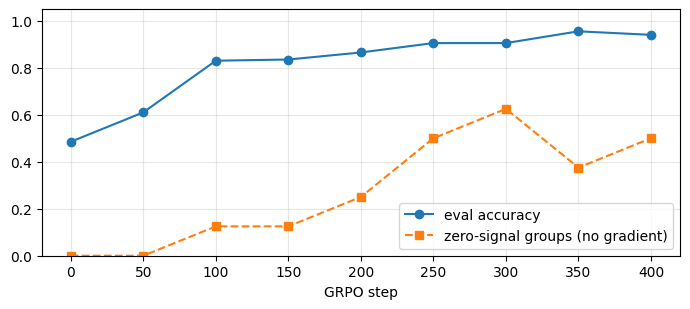

In [16]:
import matplotlib.pyplot as plt

steps  = [h[0] for h in history]
accs   = [h[3] for h in history]
zeros  = [h[2] for h in history]

fig, ax = plt.subplots(figsize=(7, 3.2))
ax.plot(steps, accs, "o-", label="eval accuracy")
ax.plot(steps, zeros, "s--", label="zero-signal groups (no gradient)")
ax.set_xlabel("GRPO step"); ax.set_ylim(0, 1.05); ax.legend(); ax.grid(alpha=.3)
plt.tight_layout(); plt.show()

The two curves are mirror images, and that's the trap:

- at accuracy ≈ 50%, almost every group is mixed → every prompt teaches something;
- as accuracy climbs, more groups come back **all-correct** → those prompts have become *too easy* and now teach nothing;
- (a weak model has the mirror problem: groups come back all-wrong — *too hard*, also nothing.)

The better your model gets, the more of your compute buys zero gradient — unless you keep re-aiming the data at the *current* frontier of difficulty: probe with the current model, drop prompts it always solves or never solves, keep the middle. Doing this well (DAPO's dynamic sampling, difficulty scheduling, the fraud-project version of the same idea) is **chapter 10** of the course.

## 12. Bonus — a taste of on-policy distillation (chapter 11 preview)

Remember §7's blunt rule: every token inherits the whole response's advantage. In response `'10.'`, the tokens `'1'`, `'0'` and `'.'` all got the same −0.58 — GRPO has no idea *where* the mistake was. The end-of-answer `'.'` did nothing wrong, and it got punished anyway.

We now have something better sitting in memory: the **finished 95% model** — a *teacher*. And `ref`, the frozen pre-RL snapshot, is a **48% student**. On-policy distillation (Thinking Machines Lab, 2025) grades every student token individually: sample from the *student*, then per token compare the two models' log-probs:

$$\text{per-token advantage} = -\big(\log\pi_{student}(x_t) - \log\pi_{teacher}(x_t)\big)$$

(the sampled estimate of the **reverse KL**, negated — in their published pseudocode this is literally `advantages = -reverse_kl`). Run it on the §5 microscope group, which *was* sampled from the student:

In [17]:
student, teacher = ref, model      # pre-RL snapshot vs RL-finished model
with torch.no_grad():
    s_lp, _ = response_logprobs(student, full, P, resp_len)
    t_lp, _ = response_logprobs(teacher, full, P, resp_len)

for i in [2, 0]:
    print(f"response {i}: {decode(group[i])!r}   (GRPO gave EVERY token adv {adv[i].item():+.2f})")
    for j, tok in enumerate(group[i]):
        col = P - 1 + j
        s, t = s_lp[i, col].exp().item(), t_lp[i, col].exp().item()
        a = (t_lp[i, col] - s_lp[i, col]).item()
        print(f"   '{decode([tok])}':  student p={s:.2f}   teacher p={t:.2f}   per-token advantage {a:+.2f}")
    print()

response 2: '7.'   (GRPO gave EVERY token adv +1.73)
   '7':  student p=0.58   teacher p=0.97   per-token advantage +0.50
   '.':  student p=1.00   teacher p=1.00   per-token advantage +0.00

response 0: '10.'   (GRPO gave EVERY token adv -0.58)
   '1':  student p=0.26   teacher p=0.01   per-token advantage -3.44
   '0':  student p=0.09   teacher p=0.23   per-token advantage +0.92
   '.':  student p=1.00   teacher p=1.00   per-token advantage -0.00



Read the wrong response `'10.'`: the teacher slams the **first** token `'1'` (that's where the answer went wrong), and leaves the innocent `'.'` alone — while GRPO had punished all three equally. Every token now carries its own signal: this is why on-policy distillation can match RL's result at a fraction of the compute (RL pays G whole rollouts for ~1 bit — "right or wrong"; the teacher grades N tokens per rollout). The full story — including when you *can't* use it because there is no teacher — is **chapter 11**.

## 13. What's toy here vs. the real thing

| in this notebook | in production (e.g. DeepSeek-R1, Qwen) |
|---|---|
| `generate()` in the training process | a separate **inference engine** (vLLM / SGLang) on other GPUs — and its probabilities *don't exactly match* the trainer's → chapter 12 (the MoE serving gap) |
| 1 update per rollout batch, ratio ≡ 1 | multiple epochs / async rollouts → ratio ≠ 1, the clip earns its keep (§9½) |
| verifier = `int(ans) == a+b` | math verifiers, unit-test sandboxes for code, reward models for open-ended chat |
| group size 8, prompts of one template | G = 8–64, millions of mixed prompts, curriculum-filtered (ch. 10) |
| advantage = z-score per group | same formula (DeepSeekMath eq. 3); variants: Dr. GRPO drops the /std, DAPO drops the KL and filters zero-signal groups |
| β = 0.02 KL to the pretrain snapshot | same idea; some reasoning runs set β = 0 and rely on other guards |
| 58k params, 13 tokens | 7B–671B params, 100k+ tokens — but **not one line of the update rule changes** |

**Where to go next in the course:** chapter 8 re-walks this update with diagrams · chapter 9: on-policy vs off-policy · chapter 10: the difficulty curriculum · chapter 11: on-policy distillation · chapter 12: MoE training-vs-serving mismatch.

*Reference: GRPO was introduced in DeepSeekMath (Shao et al., 2024, arXiv:2402.03300) and powers DeepSeek-R1 (2501.12948).*